In [1]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt 
import os
import numpy as np
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import jaccard_score #模型評估：量化預測的質量
from sklearn import metrics
from sklearn import preprocessing
import itertools
from sklearn.model_selection import validation_curve
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
df = pd.read_csv('C:/Users/USER/Desktop/北科資料/資料科學/期末報告/heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df_target = df.groupby("target").size()
df_target

target
0    138
1    165
dtype: int64

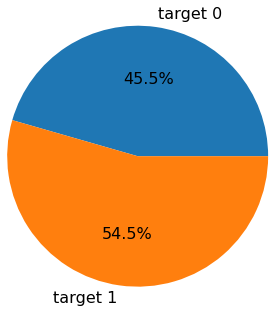

In [5]:
#圓餅圖 #超過50%的人被診斷出心臟病
plt.pie(df_target.values, labels = ["target 0", "target 1"], autopct='%1.1f%%', radius = 1.5, textprops = {"fontsize" : 16}) 
plt.show()

In [6]:
df_sex = df.groupby(["sex","target"]).size()
df_sex

sex  target
0    0          24
     1          72
1    0         114
     1          93
dtype: int64

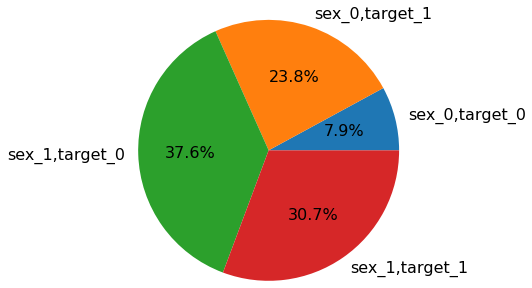

In [7]:
#男性患有心臟病的比例為30.7%，略高於女性
plt.pie(df_sex.values, labels = ["sex_0,target_0", "sex_0,target_1", "sex_1,target_0", "sex_1,target_1"],autopct='%1.1f%%',radius = 1.5, textprops = {"fontsize" : 16})
plt.show()

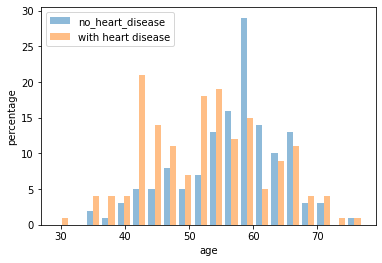

In [8]:
#40歲以上的人患有心臟病的風險更高
plt.hist([df[df.target==0].age, df[df.target==1].age], bins = 20, alpha = 0.5, label = ["no_heart_disease","with heart disease"])
plt.xlabel("age")
plt.ylabel("percentage")
plt.legend()
plt.show()

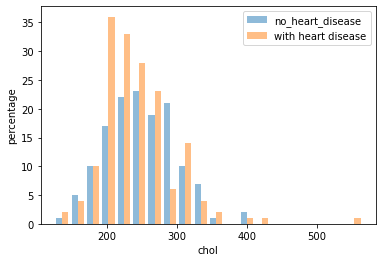

In [9]:
#患有心臟病的人的膽固醇含量超過 200 毫克/分升。 據研究，chol的正常值應低於200mg/dl。
plt.hist([df[df.target==0].chol, df[df.target==1].chol], bins = 20, alpha = 0.5, label = ["no_heart_disease","with heart disease"])
plt.xlabel("chol")
plt.ylabel("percentage")
plt.legend()
plt.show()

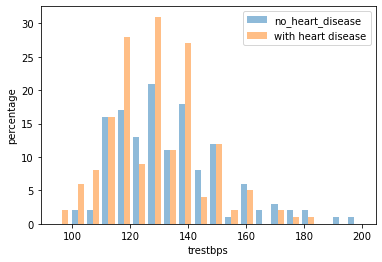

In [10]:
#理想的血壓應低於120 mmHg。 無論患者是否患有心臟病，50%以上的患者血壓較高。
plt.hist([df[df.target==0].trestbps, df[df.target==1].trestbps], bins = 20, alpha = 0.5, label = ["no_heart_disease","with heart disease"])
plt.xlabel("trestbps")
plt.ylabel("percentage")
plt.legend()
plt.show()

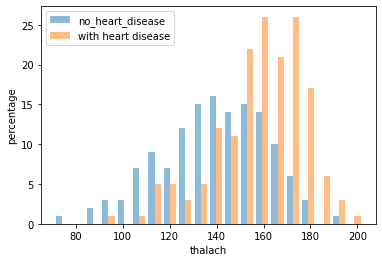

In [11]:
#最大心率與年齡呈負相關，結果心臟病者的中位數更高
plt.hist([df[df.target==0].thalach, df[df.target==1].thalach], bins = 20, alpha = 0.5, label = ["no_heart_disease","with heart disease"])
plt.xlabel("thalach")
plt.ylabel("percentage")
plt.legend()
plt.show()

In [12]:
df_1 = df[["age", "trestbps", "chol", "thalach", "oldpeak"]]
df_1.describe()

,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,131.623762,246.264026,149.646865,1.039604
std,9.082101,17.538143,51.830751,22.905161,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,47.500000,120.000000,211.000000,133.500000,0.000000
50%,55.000000,130.000000,240.000000,153.000000,0.800000
75%,61.000000,140.000000,274.500000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000


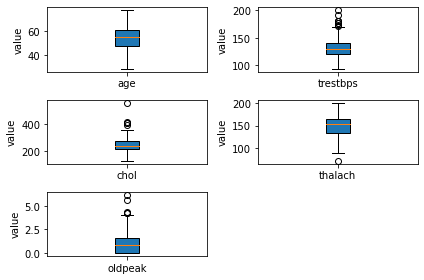

In [13]:
#檢查離群值，除了年齡外，每個特徵都有異常值，3 sigma範圍內的異常值
for item in df_1.columns:
    plt.subplot(3,2,list(df_1.columns).index(item)+1)
    plt.boxplot(df_1[item], patch_artist=True, labels = [item])
    plt.ylabel("value")
plt.tight_layout()
plt.show()

In [14]:
infor = df.describe()

df2 = df[df.trestbps < infor.loc["mean", "trestbps"] + 3 * infor.loc["std", "trestbps"]]
df3 = df2[df.chol < infor.loc["mean", "chol"] + 3 * infor.loc["std", "chol"]]
df4 = df3[df.thalach > infor.loc["mean", "thalach"] - 3 * infor.loc["std", "thalach"]]
df_new = df4[df.oldpeak < infor.loc["mean", "oldpeak"] + 3 * infor.loc["std", "oldpeak"]]
df_new.head()

C:\Users\USER\AppData\Local\Temp/ipykernel_10408/2232066516.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df3 = df2[df.chol < infor.loc["mean", "chol"] + 3 * infor.loc["std", "chol"]]
C:\Users\USER\AppData\Local\Temp/ipykernel_10408/2232066516.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df4 = df3[df.thalach > infor.loc["mean", "thalach"] - 3 * infor.loc["std", "thalach"]]
C:\Users\USER\AppData\Local\Temp/ipykernel_10408/2232066516.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_new = df4[df.oldpeak < infor.loc["mean", "oldpeak"] + 3 * infor.loc["std", "oldpeak"]]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [15]:
df_new.cp = df_new.cp.map({0:"asymptomatic", 1: "typical angina", 2:"atypical angina", 3:"non-anginal pain"})
df_new.sex = df_new.sex.map({0:"Female", 1:"Male"}) 
df_new.exang = df_new.exang.map({0:"exercise did not induce angina", 1:"exercise induced angina"})
df_new.slope = df_new.slope.map({1:"upsloping", 2:"flat", 3:"downsloping"})
df_new.thal = df_new.thal.map({1:"normal",2:"fixed defect", 3:"reversable defect"})
df_new = pd.get_dummies(df_new, drop_first = True)
df_new.head(10)

C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\generic.py:5516: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[name] = value


,age,trestbps,chol,fbs,restecg,thalach,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal pain,cp_typical angina,exang_exercise induced angina,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,1,0,150,2.3,0,1,1,0,1,0,0,0,1,0
1,37,130,250,0,1,187,3.5,0,1,1,1,0,0,0,0,0,0
2,41,130,204,0,0,172,1.4,0,1,0,0,0,1,0,0,0,0
3,56,120,236,0,1,178,0.8,0,1,1,0,0,1,0,0,0,0
4,57,120,354,0,1,163,0.6,0,1,0,0,0,0,1,0,0,0
5,57,140,192,0,1,148,0.4,0,1,1,0,0,0,0,1,1,0
6,56,140,294,0,0,153,1.3,0,1,0,0,0,1,0,1,0,0
7,44,120,263,0,1,173,0.0,0,1,1,0,0,1,0,0,0,1
8,52,172,199,1,1,162,0.5,0,1,1,1,0,0,0,0,0,1
9,57,150,168,0,1,174,1.6,0,1,1,1,0,0,0,0,0,0


In [16]:
X = df_new.drop('target', axis=1)
y = df_new["target"].astype("int").values
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=10)

In [17]:
model = XGBClassifier()
param = dict(model_max_depth=[3,5,7], model_learning_rate=[0.001,0.01, 0.1], model_n_estimators=[100,500])

cv = GridSearchCV(model, param_grid=param, cv=10)
cv

GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None,
                                     enable_categorical=False, gamma=None,
                                     gpu_id=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None, max_delta_step=None,
                                     max_depth=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     n_estimators=100, n_jobs=None,
                                     num_parallel_tree=None, predictor=None,
                                     random_state=None, reg_alpha=None,
                                     reg_lambda=None, scale_pos_weigh

In [18]:
cv.fit(X_train, y_train)
test_pred = cv.predict(X_test)

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[14:45:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[14:45:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[14:45:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a fa

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of 

[14:45:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[14:45:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[14:45:46] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a fa

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


...

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[14:46:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[14:46:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[14:46:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a fa

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


[14:46:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


[14:46:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[14:46:07] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "model_learning_rate", "model_max_depth", "model_n_estimators" } might not be used.

  This could be a fa

C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)
C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


In [20]:
max_depth_of_model = cv.best_estimator_.max_depth
best_learning_rate = cv.best_estimator_.learning_rate
best_estimator = cv.best_estimator_.n_estimators
best_reg_lambda = cv.best_estimator_.reg_lambda

model = XGBClassifier(max_depth=max_depth_of_model, learning_rate=best_learning_rate, n_estimators= best_estimator,n_jobs=1,)
model.fit(X_train, y_train)
yhat = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
accuracy_score(yhat,y_test)
#模型準確率為82.4%

[14:46:08] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:1115: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.


C:\ProgramData\Anaconda3\lib\site-packages\xgboost\sklearn.py:1224: UserWarning: The use of label encoder in XGBClassifier is deprecated and will be removed in a future release. To remove this warning, do the following: 1) Pass option use_label_encoder=False when constructing XGBClassifier object; and 2) Encode your labels (y) as integers starting with 0, i.e. 0, 1, 2, ..., [num_class - 1].
  warnings.warn(label_encoder_deprecation_msg, UserWarning)


0.8108108108108109

In [22]:
from sklearn.datasets import load_iris
from sklearn import tree
from sklearn.model_selection import train_test_split

In [24]:
#根據重要性對特徵進行排序
importances = model.feature_importances_
importances

array([0.03845724, 0.03478841, 0.02509091, 0.02446581, 0.04547273,
       0.03570224, 0.09191208, 0.16961423, 0.04933538, 0.08676931,
       0.03785898, 0.07262262, 0.04939058, 0.09882559, 0.        ,
       0.13969389], dtype=float32)

In [25]:
#將特徵排列為字典數據結構
inducies = np.argsort(importances)[::-1]
inducies

array([ 7, 15, 13,  6,  9, 11, 12,  8,  4,  0, 10,  5,  1,  2,  3, 14],
      dtype=int64)

In [26]:
feature_dict = dict()
for idx in inducies:
    feature_dict[list(df_new.drop("target",1).columns)[idx]] = float(importances[idx])
feature_dict

C:\Users\USER\AppData\Local\Temp/ipykernel_18128/3468341758.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  feature_dict[list(df_new.drop("target",1).columns)[idx]] = float(importances[idx])


{'ca': 0.16961422562599182,
 'thal_reversable defect': 0.13969388604164124,
 'slope_upsloping': 0.09882558882236481,
 'oldpeak': 0.09191207587718964,
 'cp_atypical angina': 0.08676931262016296,
 'cp_typical angina': 0.0726226195693016,
 'exang_exercise induced angina': 0.04939057677984238,
 'sex_Male': 0.049335382878780365,
 'restecg': 0.045472726225852966,
 'age': 0.038457240909338,
 'cp_non-anginal pain': 0.037858981639146805,
 'thalach': 0.035702235996723175,
 'trestbps': 0.034788407385349274,
 'chol': 0.025090908631682396,
 'fbs': 0.024465812370181084,
 'thal_normal': 0.0}

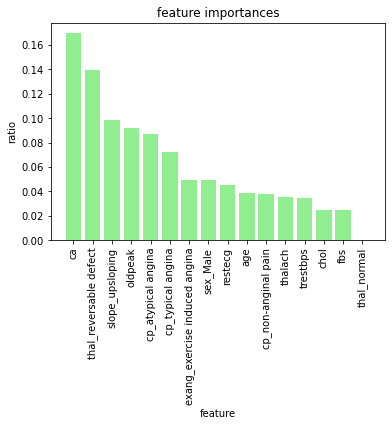

In [27]:
#thal_normal不是重要特徵，需刪除；可逆缺陷和ca較其他高
y_pos = np.arange(len(feature_dict.keys()))
plt.bar(y_pos, list(feature_dict.values()), align = "center",color = "lightgreen")
plt.xticks(y_pos, list(feature_dict.keys()), rotation = 90)
plt.xlabel("feature")
plt.ylabel("ratio")
plt.title("feature importances")
plt.show()

In [28]:
#假陰性數量為1，代表召回率會在90%以上
tp,fn,fp,tn = confusion_matrix(y_test, yhat, labels=[1,0]).ravel()
tp,tn,fp,fn

(32, 28, 13, 1)

In [29]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()
    return ""

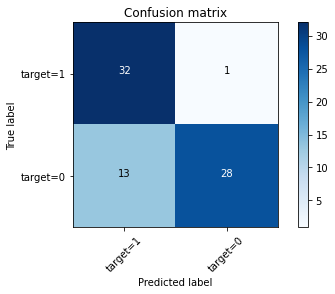

In [30]:
#混淆矩陣，在此型數據中，召回率比準確率重要的多
cmx = confusion_matrix(y_test, yhat, labels=[1,0])
print(plot_confusion_matrix(cmx, classes=['target=1','target=0'],normalize= False,  title='Confusion matrix'))

In [31]:
#召回率為97#，即仍有3%被誤診
precision_rate = tp / (tp + fp)
recall_rate = tp / (tp + fn)
print("The precision rate is: ", precision_rate)
print("The recall rate is: ", recall_rate)

The precision rate is:  0.7111111111111111
The recall rate is:  0.9696969696969697


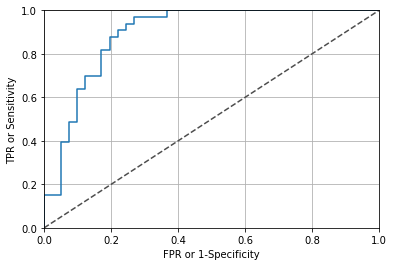

In [32]:
#ROC curve
fpr, tpr, threshold =roc_curve(y_test, y_proba)
fig, ax = plt.subplots()
ax.plot(fpr,tpr)
ax.plot([0,1], [0,1], transform = ax.transAxes, ls="--", c="0.3")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.xlabel("FPR or 1-Specificity")
plt.ylabel("TPR or Sensitivity")
plt.rcParams["font.size"] = 10
plt.grid(True)
plt.show()

In [33]:
#AUC；如果AUC在0.5~1的範圍內，說明模型具有預測價值。 分數越高，模型越好。 此外，如果 AUC 等於 1，該模型將是一個完美的分類器。
auc(fpr, tpr)

0.893569844789357

In [34]:
import eli5
from eli5.sklearn import PermutationImportance

In [35]:
#ca和可逆缺陷對心臟病的療效顯著，男性患心臟病的可能性較高，最大心率為重要作用，呈正相關，trestbs（靜息血壓）並未很高
perm = PermutationImportance(model, random_state=1).fit(X_test, y_test)
eli5.show_weights(perm, feature_names = df_new.drop("target", 1).columns.tolist())

C:\Users\USER\AppData\Local\Temp/ipykernel_18128/2859685240.py:3: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  eli5.show_weights(perm, feature_names = df_new.drop("target", 1).columns.tolist())


Weight,Feature
0.0703 ± 0.0878,ca
0.0351 ± 0.0276,thal_reversable defect
0.0297 ± 0.0202,sex_Male
0.0135 ± 0.0171,slope_upsloping
0.0081 ± 0.0405,oldpeak
0.0081 ± 0.0132,trestbps
0.0081 ± 0.0216,thalach
0.0054 ± 0.0132,cp_typical angina
0.0027 ± 0.0108,exang_exercise induced angina
0.0027 ± 0.0108,cp_non-anginal pain


In [36]:
from sklearn.inspection import partial_dependence
from sklearn.inspection import plot_partial_dependence

In [47]:
feature_dict = dict(enumerate(df_new.drop("target", 1).columns))
feature_dict

In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only


{0: 'age',
 1: 'trestbps',
 2: 'chol',
 3: 'fbs',
 4: 'restecg',
 5: 'thalach',
 6: 'oldpeak',
 7: 'ca',
 8: 'sex_Male',
 9: 'cp_atypical angina',
 10: 'cp_non-anginal pain',
 11: 'cp_typical angina',
 12: 'exang_exercise induced angina',
 13: 'slope_upsloping',
 14: 'thal_normal',
 15: 'thal_reversable defect'}

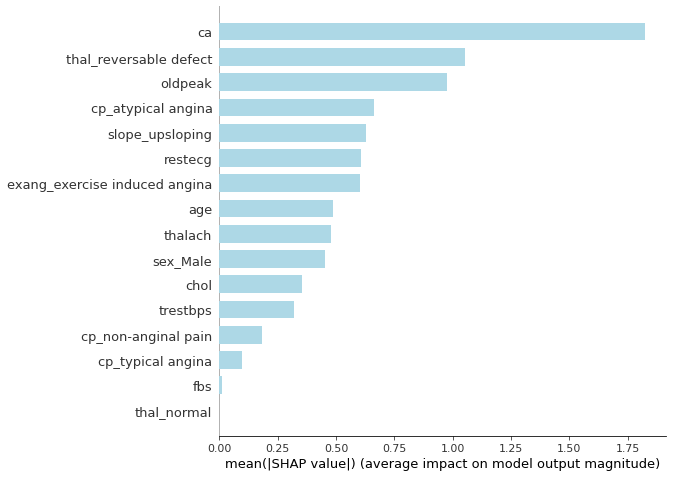

In [48]:
#各特徵數據分布
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names = list(feature_dict.values()), plot_type = "bar", color = "lightblue")

In [ ]:
#結論
多年來，心血管疾病是頭號殺手。我認為原因是我們對心髒病和生活習慣缺乏了解。根據模型和特徵分析，我們知道哪些特徵可以做定期的自查。

我認為最明顯的症狀是胸痛。胸痛分為三種類型，但只有非典型心絞痛與心髒病密切相關。無論您有哪種類型的胸痛，請去看醫生以防萬一。

另外，大家要時刻留意靜息血壓。理想的靜息血壓低於120mmHg，但如果你的血壓遠低於120mmHg，就說明你患心髒病的風險很高。此外，當血壓高於150mmHg時，問題不僅僅在於心臟。

有很多可以測量心率的電子設備，因此您可以更輕鬆地監測自己的心率。記錄最大心率以確保您的心臟仍然健康。一旦利率逐年上升，那一定是你有問題。

再健康的人，也得每年體檢，因為其他的功能不是自己能照顧到的。最後，不要忘記我們年齡越大，風險就越大。